# Analiza tekstur: GLCM i klasyfikacja KTH-TIPS

## 1. GLCM — cechy i biblioteki

Cechy Haralicka używane w notatniku: `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, `ASM`, `entropy`.

Biblioteki z gotowym GLCM: **scikit-image** (`graycomatrix`, `graycoprops`) i **mahotas** (`haralick`). Używamy scikit-image.

## 2. Importy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from skimage.feature import graycomatrix, graycoprops
from skimage.util import img_as_ubyte

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

RNG = 42
np.random.seed(RNG)

## 3. Wczytanie KTH-TIPS (wszystkie 10 klas, 81 obrazów grayscale 200×200 na klasę)

In [6]:
DATA_DIR = Path('original')
CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

def load_class_images(class_name, data_dir=DATA_DIR):
    folder = data_dir / class_name
    images = []
    for p in sorted(folder.glob('*.gif')):
        img = np.array(Image.open(p).convert('L'))
        images.append(img)
    return images

dataset = {c: load_class_images(c) for c in CLASSES}
print(f'Liczba klas: {len(CLASSES)}')
for c, imgs in dataset.items():
    print(f'  {c:18s}  N={len(imgs):3d}  shape={imgs[0].shape}  dtype={imgs[0].dtype}')

Liczba klas: 0


### 3.1 Podgląd klas

In [7]:
N_PREVIEW = 3
fig, axes = plt.subplots(len(CLASSES), N_PREVIEW, figsize=(3 * N_PREVIEW, 2.5 * len(CLASSES)))
for row, c in enumerate(CLASSES):
    step = max(1, len(dataset[c]) // N_PREVIEW)
    samples = dataset[c][::step][:N_PREVIEW]
    for col, img in enumerate(samples):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[row, col].axis('off')
    axes[row, 0].set_title(c, fontsize=11, loc='left')
plt.suptitle('Przykładowe obrazy — wszystkie klasy KTH-TIPS', fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 900x0 with 0 Axes>

## 4. GLCM i cechy dla przykładowego obrazu z każdej klasy

Parametry: `levels=32`, `distances=[1,3]`, `angles=[0, π/4, π/2, 3π/4]`, `symmetric=True`, `normed=True`.

In [4]:
LEVELS = 32
DISTANCES = [1, 3]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
PROPS = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

def quantize(img, levels=LEVELS):
    return (img.astype(np.float32) / 256.0 * levels).astype(np.uint8)

def glcm_entropy(glcm):
    eps = 1e-12
    p = glcm
    return -np.sum(p * np.log2(p + eps), axis=(0, 1))

example_imgs = {c: dataset[c][0] for c in CLASSES}

rows = []
for c, img in example_imgs.items():
    q = quantize(img)
    glcm = graycomatrix(q, distances=DISTANCES, angles=ANGLES,
                         levels=LEVELS, symmetric=True, normed=True)
    row = {'class': c}
    for prop in PROPS:
        vals = graycoprops(glcm, prop)
        row[prop] = float(vals.mean())
    row['entropy'] = float(glcm_entropy(glcm).mean())
    rows.append(row)

print(f'{"class":18s}' + ''.join(f'{p:>14s}' for p in PROPS + ['entropy']))
for r in rows:
    print(f"{r['class']:18s}" + ''.join(f"{r[p]:>14.4f}" for p in PROPS + ['entropy']))

class                   contrast dissimilarity   homogeneity        energy   correlation           ASM       entropy
aluminium_foil           23.4662        2.8424        0.4626        0.1530        0.8934        0.0237        7.8249
brown_bread               2.1720        0.9918        0.6075        0.1666        0.8703        0.0285        5.7981
corduroy                  0.8054        0.6058        0.7170        0.2253        0.8940        0.0517        4.6996
cotton                    1.2144        0.8026        0.6397        0.2828        0.5097        0.0811        4.0055
cracker                   2.1120        1.0160        0.5919        0.1510        0.8843        0.0234        5.9951
linen                     2.9036        1.2580        0.5217        0.1615        0.7093        0.0268        5.6759
orange_peel               0.7922        0.5637        0.7407        0.2695        0.8698        0.0736        4.4054
sandpaper                 0.4908        0.4228        0.7953    

### 4.1 Wizualizacja GLCM (skala log, d=1, θ=0°)

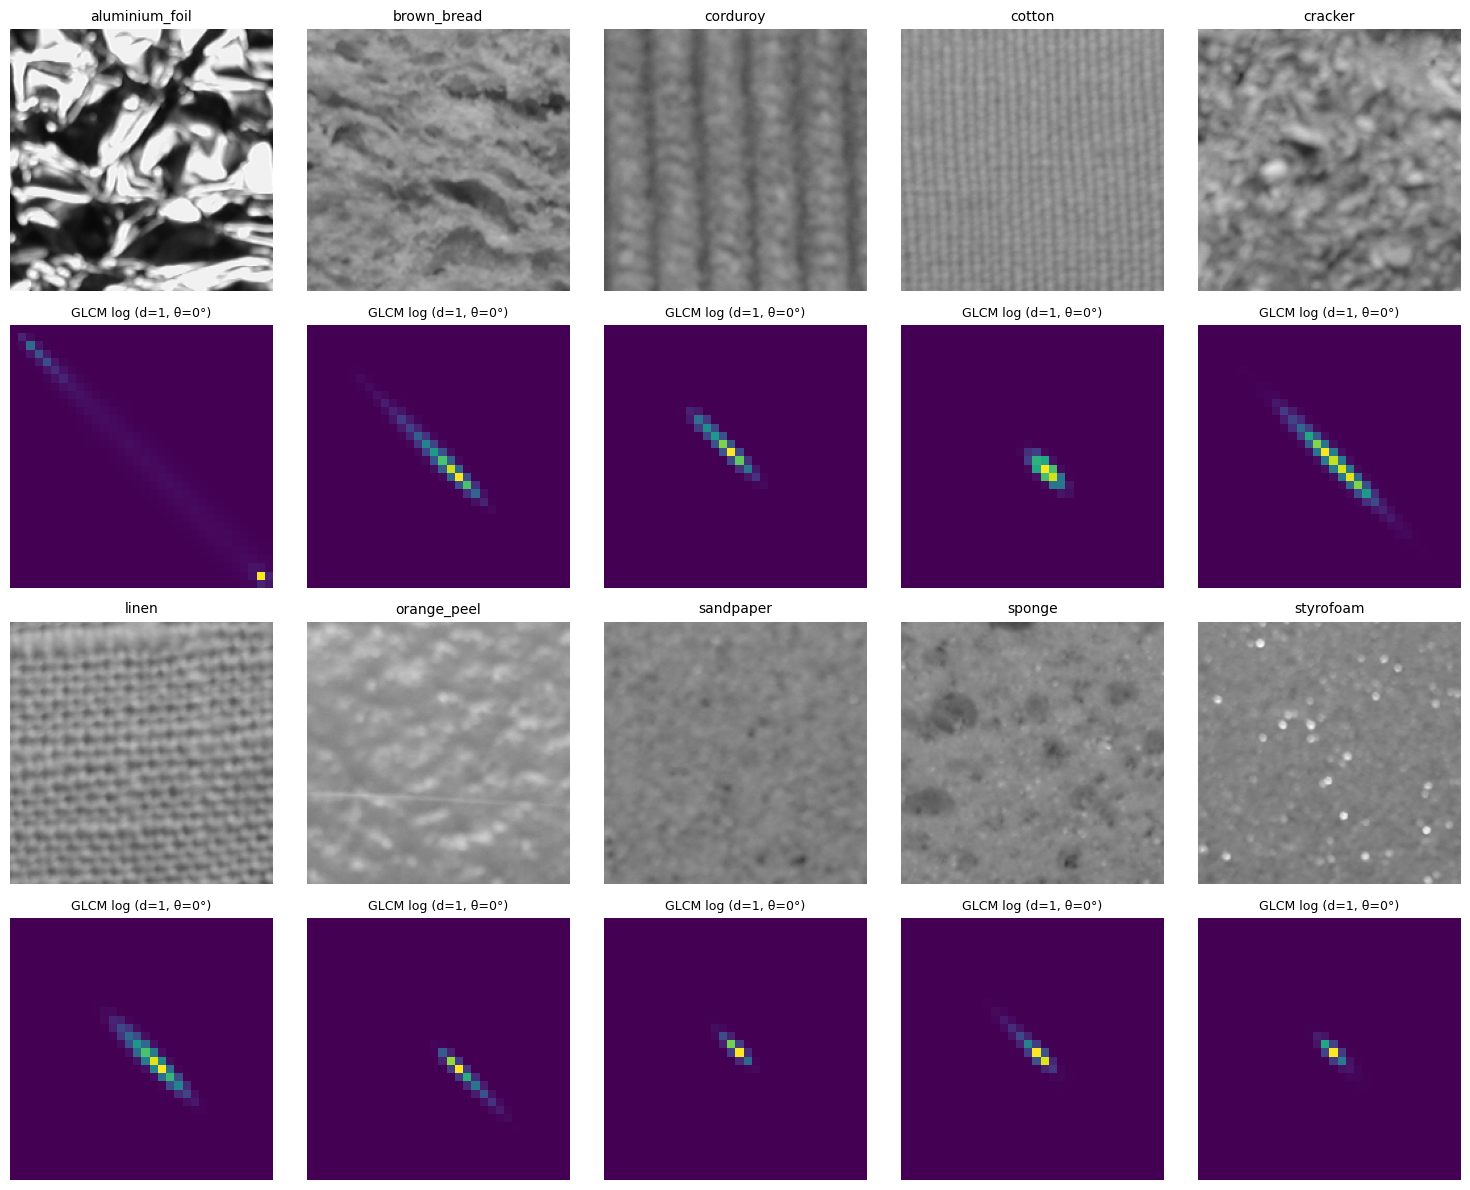

In [5]:
n = len(CLASSES)
ncols = 5
nrows_per_section = (n + ncols - 1) // ncols

fig, axes = plt.subplots(2 * nrows_per_section, ncols, figsize=(3 * ncols, 3 * nrows_per_section * 2))
for i, c in enumerate(CLASSES):
    r_img = (i // ncols) * 2
    r_glcm = r_img + 1
    col = i % ncols
    img = example_imgs[c]
    q = quantize(img)
    glcm = graycomatrix(q, distances=[1], angles=[0],
                         levels=LEVELS, symmetric=True, normed=True)
    axes[r_img, col].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[r_img, col].set_title(c, fontsize=10); axes[r_img, col].axis('off')
    axes[r_glcm, col].imshow(np.log1p(glcm[:, :, 0, 0]), cmap='viridis')
    axes[r_glcm, col].set_title('GLCM log (d=1, θ=0°)', fontsize=9)
    axes[r_glcm, col].axis('off')

for ax in axes.flat:
    if not ax.has_data() and not ax.get_title():
        ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Ekstrakcja 56 cech GLCM z całego zbioru (7 właściwości × 2 dystanse × 4 kąty)

In [6]:
def extract_features(img, levels=LEVELS, distances=DISTANCES, angles=ANGLES):
    q = quantize(img, levels)
    glcm = graycomatrix(q, distances=distances, angles=angles,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in PROPS:
        feats.append(graycoprops(glcm, prop).ravel())
    feats.append(glcm_entropy(glcm).ravel())
    return np.concatenate(feats)

feature_names = []
for prop in PROPS + ['entropy']:
    for d in DISTANCES:
        for a_deg in [0, 45, 90, 135]:
            feature_names.append(f'{prop}_d{d}_a{a_deg}')

X_list, y_list = [], []
for c in CLASSES:
    for img in dataset[c]:
        X_list.append(extract_features(img))
        y_list.append(c)

X = np.array(X_list)
y = np.array(y_list)
print(f'X shape: {X.shape}  (próbki × cechy)')
print(f'y shape: {y.shape}')
print(f'Liczba cech: {len(feature_names)}')
unique, counts = np.unique(y, return_counts=True)
print(f'Rozkład klas: {dict(zip(unique, counts))}')

X shape: (810, 56)  (próbki × cechy)
y shape: (810,)
Liczba cech: 56
Rozkład klas: {'aluminium_foil': 81, 'brown_bread': 81, 'corduroy': 81, 'cotton': 81, 'cracker': 81, 'linen': 81, 'orange_peel': 81, 'sandpaper': 81, 'sponge': 81, 'styrofoam': 81}


### 5.1 Boxploty wybranych cech wg klas

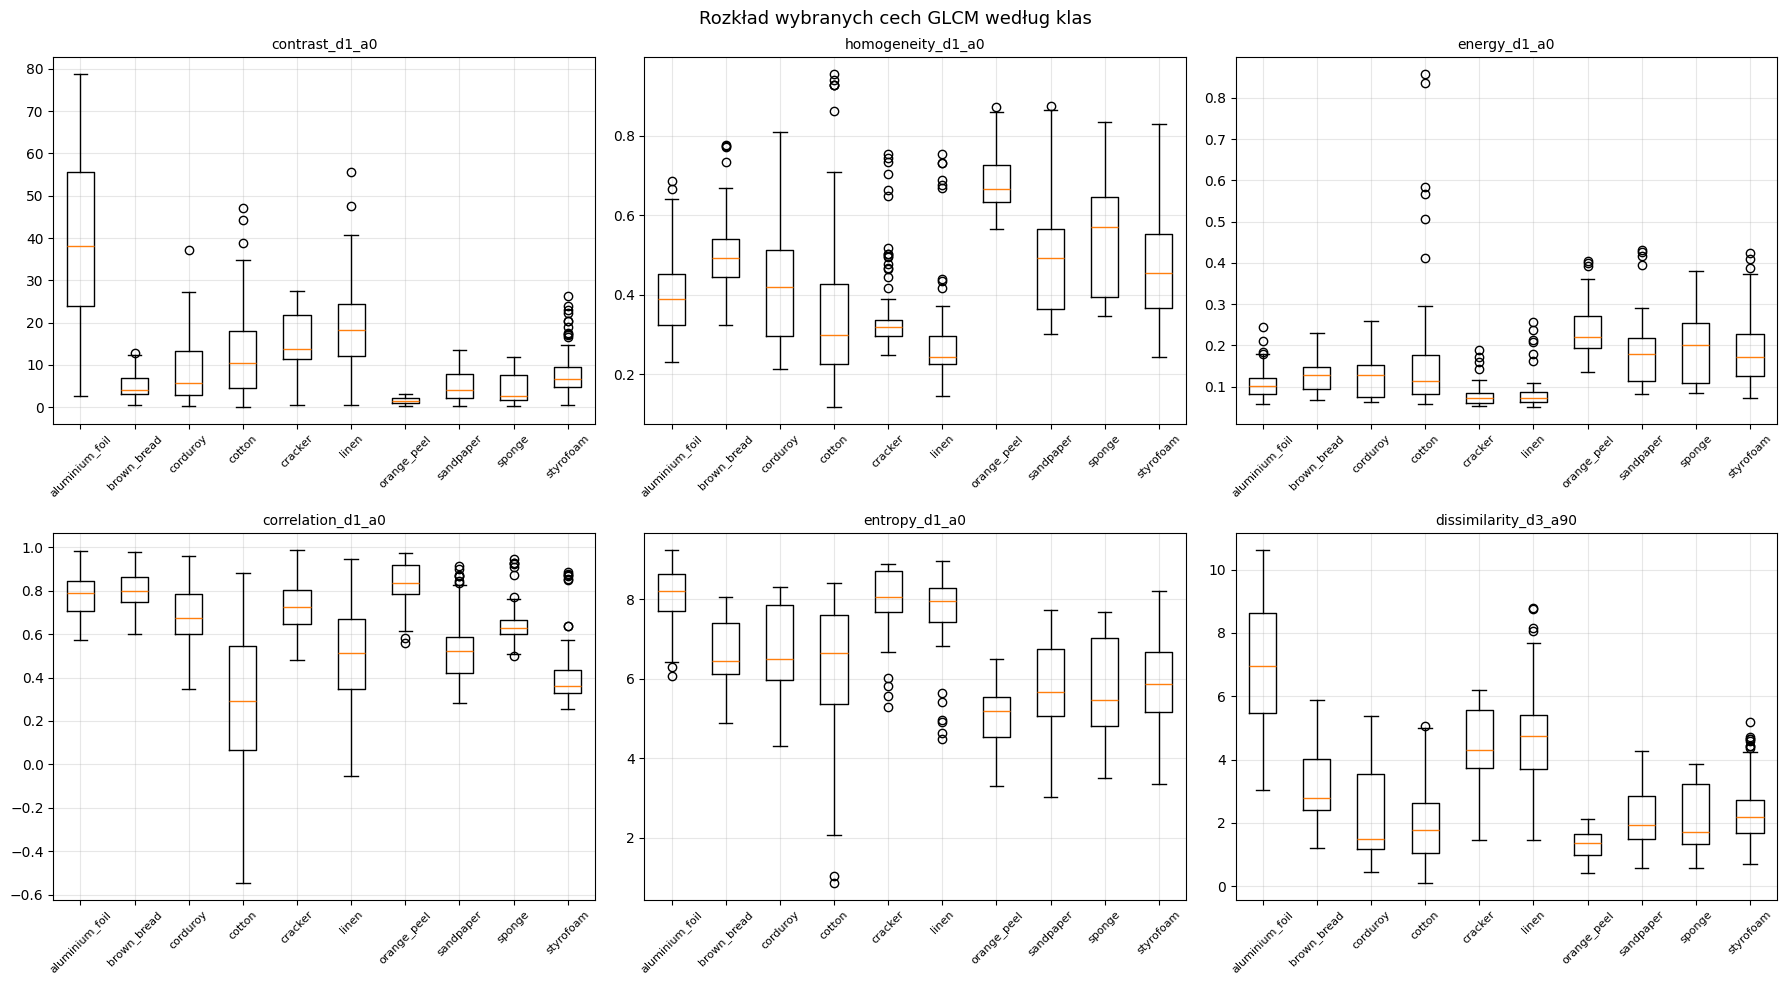

In [7]:
selected = ['contrast_d1_a0', 'homogeneity_d1_a0', 'energy_d1_a0',
            'correlation_d1_a0', 'entropy_d1_a0', 'dissimilarity_d3_a90']
idx = [feature_names.index(s) for s in selected]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, i, name in zip(axes.flat, idx, selected):
    data_per_class = [X[y == c, i] for c in CLASSES]
    ax.boxplot(data_per_class, labels=CLASSES)
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Rozkład wybranych cech GLCM według klas', fontsize=13)
plt.tight_layout(); plt.show()

## 6. Podział train/test (70/30, stratyfikowany) + standaryzacja cech

In [8]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, random_state=RNG, stratify=y_enc)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} próbek  Test: {X_test.shape[0]} próbek')
print(f'Klasy (enc): {dict(zip(le.classes_, range(len(le.classes_))))}')

Train: 567 próbek  Test: 243 próbek
Klasy (enc): {'aluminium_foil': 0, 'brown_bread': 1, 'corduroy': 2, 'cotton': 3, 'cracker': 4, 'linen': 5, 'orange_peel': 6, 'sandpaper': 7, 'sponge': 8, 'styrofoam': 9}


## 7. Klasyfikacja: kNN, Decision Tree, Random Forest, Logistic Regression

In [9]:
classifiers = {
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=RNG),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RNG),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RNG),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': clf, 'acc': acc, 'y_pred': y_pred}
    print(f'{name:22s}  accuracy = {acc:.4f}')

kNN (k=5)               accuracy = 0.7490
Decision Tree           accuracy = 0.7037
Random Forest           accuracy = 0.7901
Logistic Regression     accuracy = 0.7243


## 8. Ewaluacja: raport + macierze pomyłek

In [10]:
best_name = max(results, key=lambda n: results[n]['acc'])
print(f'Najlepszy model: {best_name}  (acc={results[best_name]["acc"]:.4f})\n')
print('Classification report dla najlepszego modelu:')
print(classification_report(y_test, results[best_name]['y_pred'], target_names=le.classes_))

Najlepszy model: Random Forest  (acc=0.7901)

Classification report dla najlepszego modelu:
                precision    recall  f1-score   support

aluminium_foil       1.00      1.00      1.00        24
   brown_bread       0.77      0.71      0.74        24
      corduroy       0.83      0.79      0.81        24
        cotton       0.94      0.60      0.73        25
       cracker       0.81      0.88      0.85        25
         linen       0.80      0.83      0.82        24
   orange_peel       0.69      0.88      0.77        25
     sandpaper       0.64      0.67      0.65        24
        sponge       0.67      0.83      0.74        24
     styrofoam       0.89      0.71      0.79        24

      accuracy                           0.79       243
     macro avg       0.80      0.79      0.79       243
  weighted avg       0.80      0.79      0.79       243



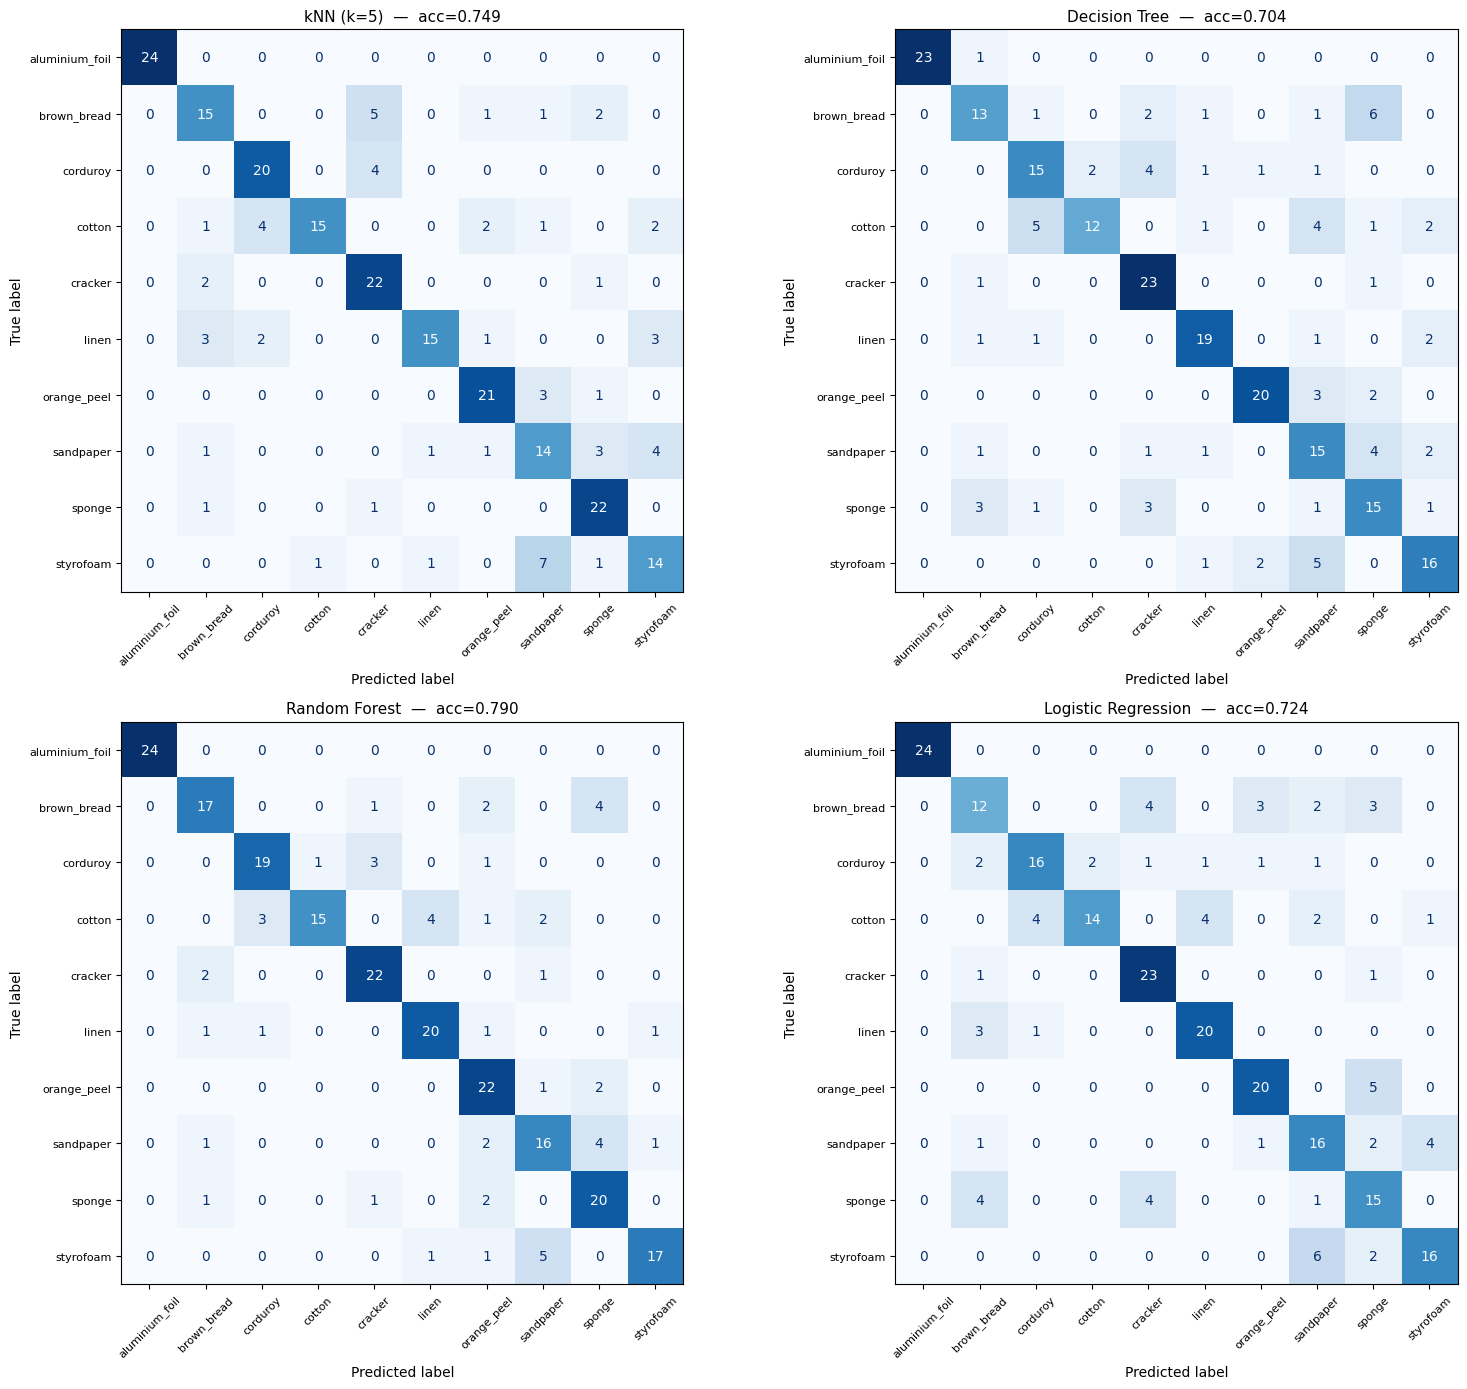

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for ax, (name, r) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{name}  —  acc={r["acc"]:.3f}', fontsize=11)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

### 8.1 Top 15 cech wg Random Forest

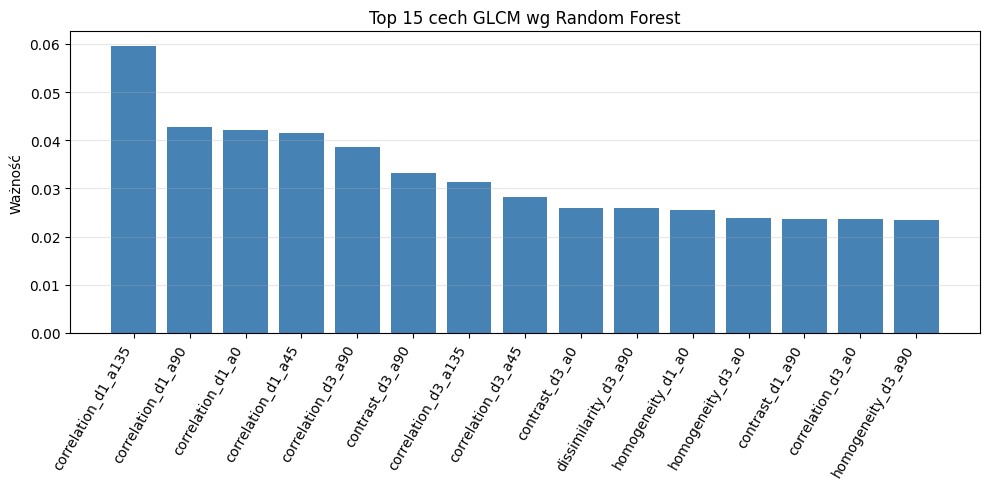

In [12]:
rf = results['Random Forest']['model']
importances = rf.feature_importances_
order = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(len(order)), importances[order], color='steelblue')
plt.xticks(range(len(order)), [feature_names[i] for i in order], rotation=60, ha='right')
plt.ylabel('Ważność')
plt.title('Top 15 cech GLCM wg Random Forest')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Wnioski

- Cechy GLCM wystarczą, żeby na 10 klasach dostać ok. 79% accuracy — sensowny wynik jak na tak proste deskryptory.
- Najlepszy wyszedł Random Forest ($acc \approx 0.79$), najsłabsze drzewo decyzyjne - mocno się przeucza.
- Folia aluminiowa (`aluminium_foil`) jest rozpoznawalna w 100% - ma zupełnie inny contrast niż reszta.
- Najwięcej pomyłek jest między klasami, które wyglądają podobnie (`bread`/`sponge`, `cotton`/`linen`, `syrofoam`/`sandpaper`).
- Dodanie cech liczonych dla różnych kątów i dystansów pomaga - tekstury kierunkowe (corduroy) dają inne wartości niż izotropowe.